# Quiz 1

In [ ]:
import os
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 讓 notebook 不論從哪個目錄啟動，都能找到 Code 套件
BASE_DIR = os.path.abspath('')
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

import Code.quiz1 as q1
from importlib import reload
reload(q1)  

IMAGE_PATH = os.path.join(BASE_DIR, 'data', 'asa.JPG')
print('影像路徑:', IMAGE_PATH, '| 存在:', os.path.isfile(IMAGE_PATH))

# 每執行一次方法就累積一筆，重跑此格會清空紀錄
records = []


影像路徑: c:\Users\Alan\python\MMIP\week1\Data\asa.JPG | 存在: True


## NumPy 實作灰階轉換

依照 ITU-R BT.601 標準，加權公式：

$$\text{Gray} = 0.299 \times R + 0.587 \times G + 0.114 \times B$$


NumPy  執行時間:   40.079 ms | 尺寸: (2048, 946) | 平均灰階: 132.78


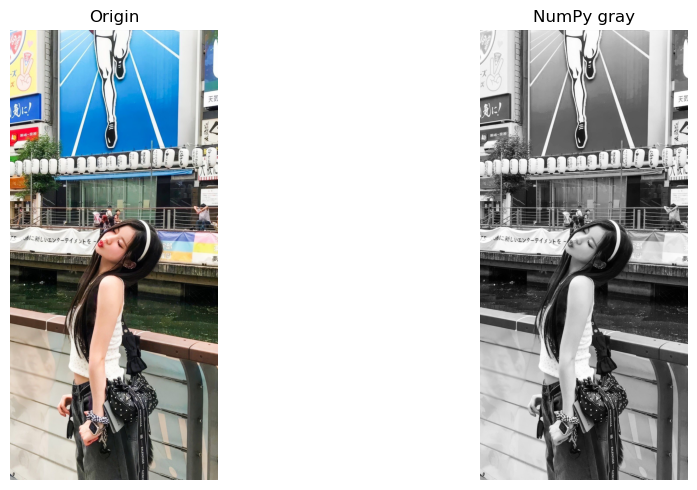

In [65]:
img_rgb, gray_numpy = q1.numpy_gray(IMAGE_PATH, records)


## OpenCV 灰階轉換

OpenCV 以 BGR 順序讀取影像，`cv2.COLOR_BGR2GRAY` 底層為 C++ 實作。


OpenCV 執行時間:    1.048 ms | 尺寸: (2048, 946) | 平均灰階: 132.78


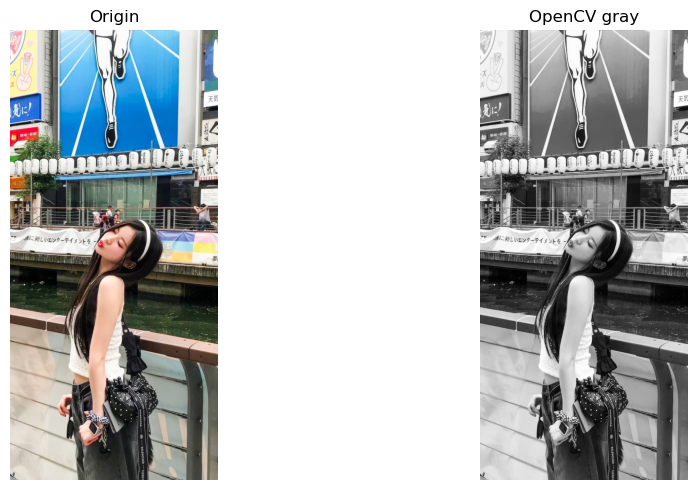

In [66]:
img_rgb_cv, gray_cv = q1.opencv_gray(IMAGE_PATH, records)


## 比較執行速度與轉換結果


=== 執行紀錄 ===
 1. NumPy    40.079 ms | 平均灰階: 132.78
 2. OpenCV    1.048 ms | 平均灰階: 132.78

=== 各方法平均 ===
NumPy    40.079 ms (共 1 次)
OpenCV    1.048 ms (共 1 次)

最大差異: 6 | 平均差異: 0.0039


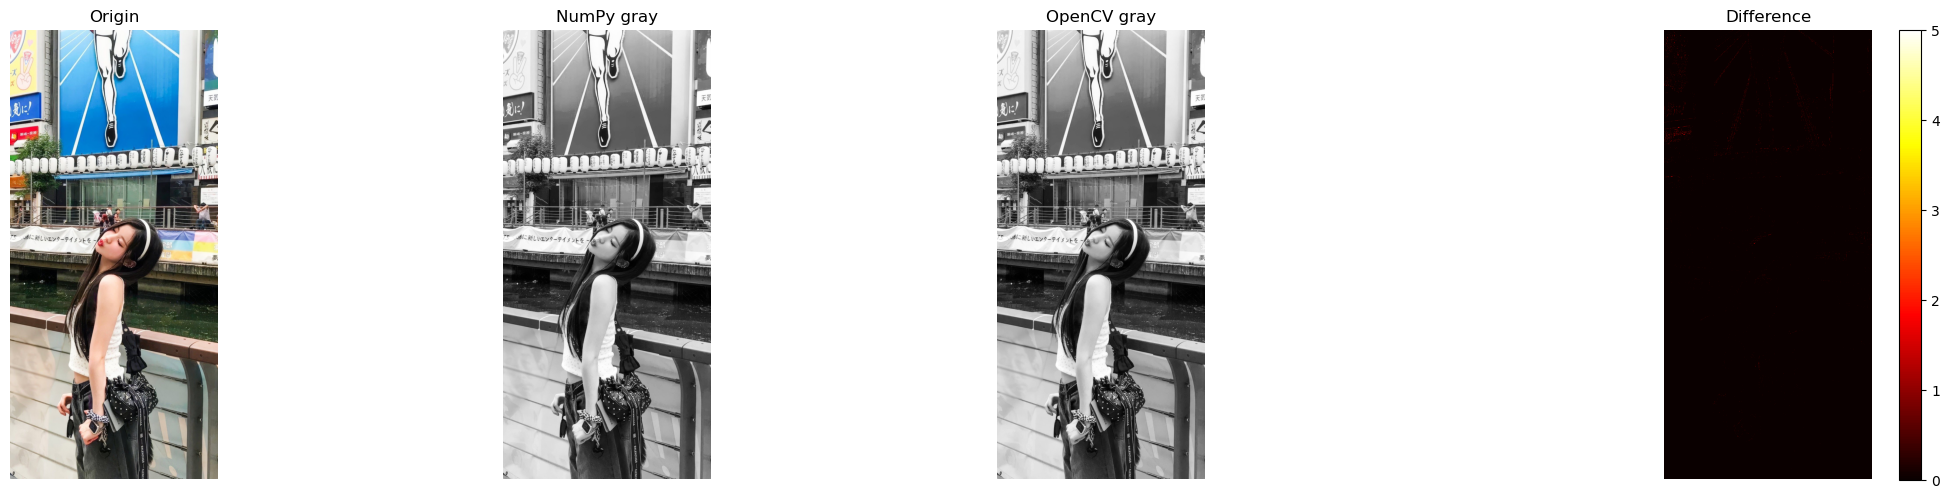

In [67]:
q1.analyze_records(records, gray_numpy, gray_cv, img_rgb)


# Quiz 2

In [ ]:
import os
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 讓 notebook 不論從哪個目錄啟動，都能找到 Code 套件
BASE_DIR = os.path.abspath('')
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

import Code.quiz2 as q2
from importlib import reload
reload(q2)  # 改完 quiz2.py 後重跑這格即可生效

IMAGE_PATH2 = os.path.join(BASE_DIR, 'data', 'quiz2.jpg')
print('影像路徑:', IMAGE_PATH2, '| 存在:', os.path.isfile(IMAGE_PATH2))

# Quiz 2 專用的紀錄清單，與 Quiz 1 的 records 分開
records2 = []


影像路徑: c:\Users\Alan\python\MMIP\week1\Data\quiz2.jpg | 存在: True


## NumPy 實作 Histogram Equalization

先統計灰階直方圖 $h(k)$，累加成累積分布 $\text{cdf}(k)=\sum_{j=0}^{k} h(j)$，再映射到 0~255：

$$s_k = \text{round}\left( \frac{\text{cdf}(k) - \text{cdf}_{\min}}{N - \text{cdf}_{\min}} \times 255 \right)$$

其中 $N$ 為總像素數、$\text{cdf}_{\min}$ 是最小的非零累積值。算完 LUT 後用 `lut[gray]` 一次完成整張圖的查表映射。


NumPy  執行時間:    4.579 ms | 尺寸: (682, 1023) | 平均灰階: 129.32


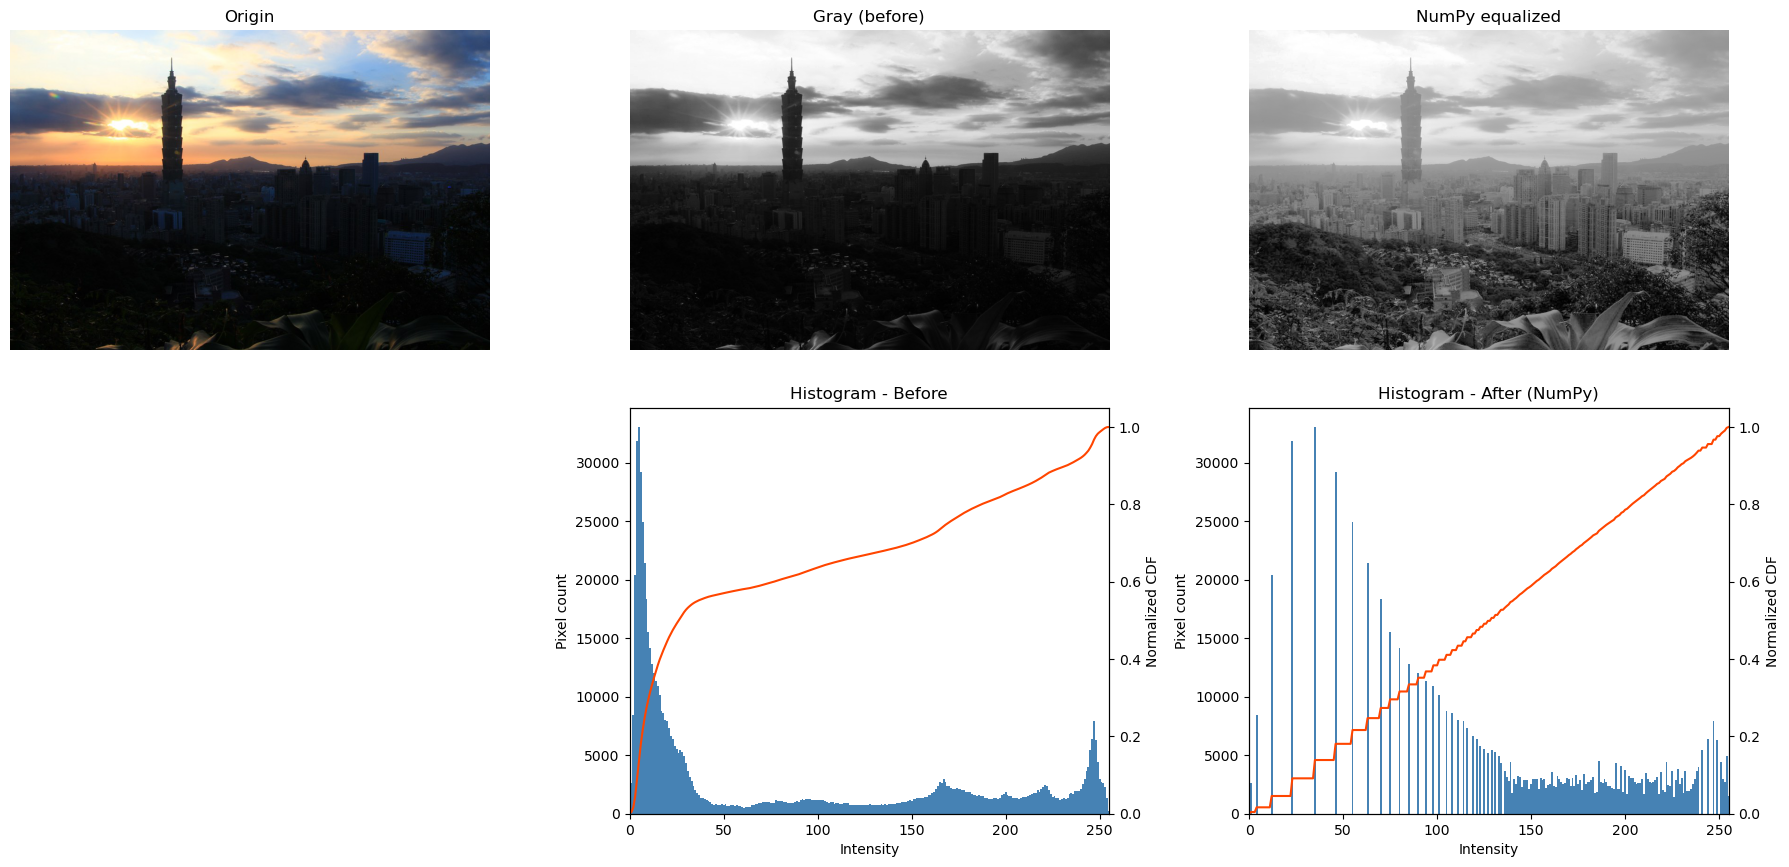

In [130]:
img_rgb2, gray2, eq_numpy = q2.Numpy_Histogram(IMAGE_PATH2, records2)


## OpenCV 實作 Histogram Equalization

`cv2.equalizeHist` 底層是 C++ 實作，使用的公式與上面完全相同，可用來驗證自己寫的版本是否正確。


OpenCV 執行時間:    0.824 ms | 尺寸: (682, 1023) | 平均灰階: 129.32


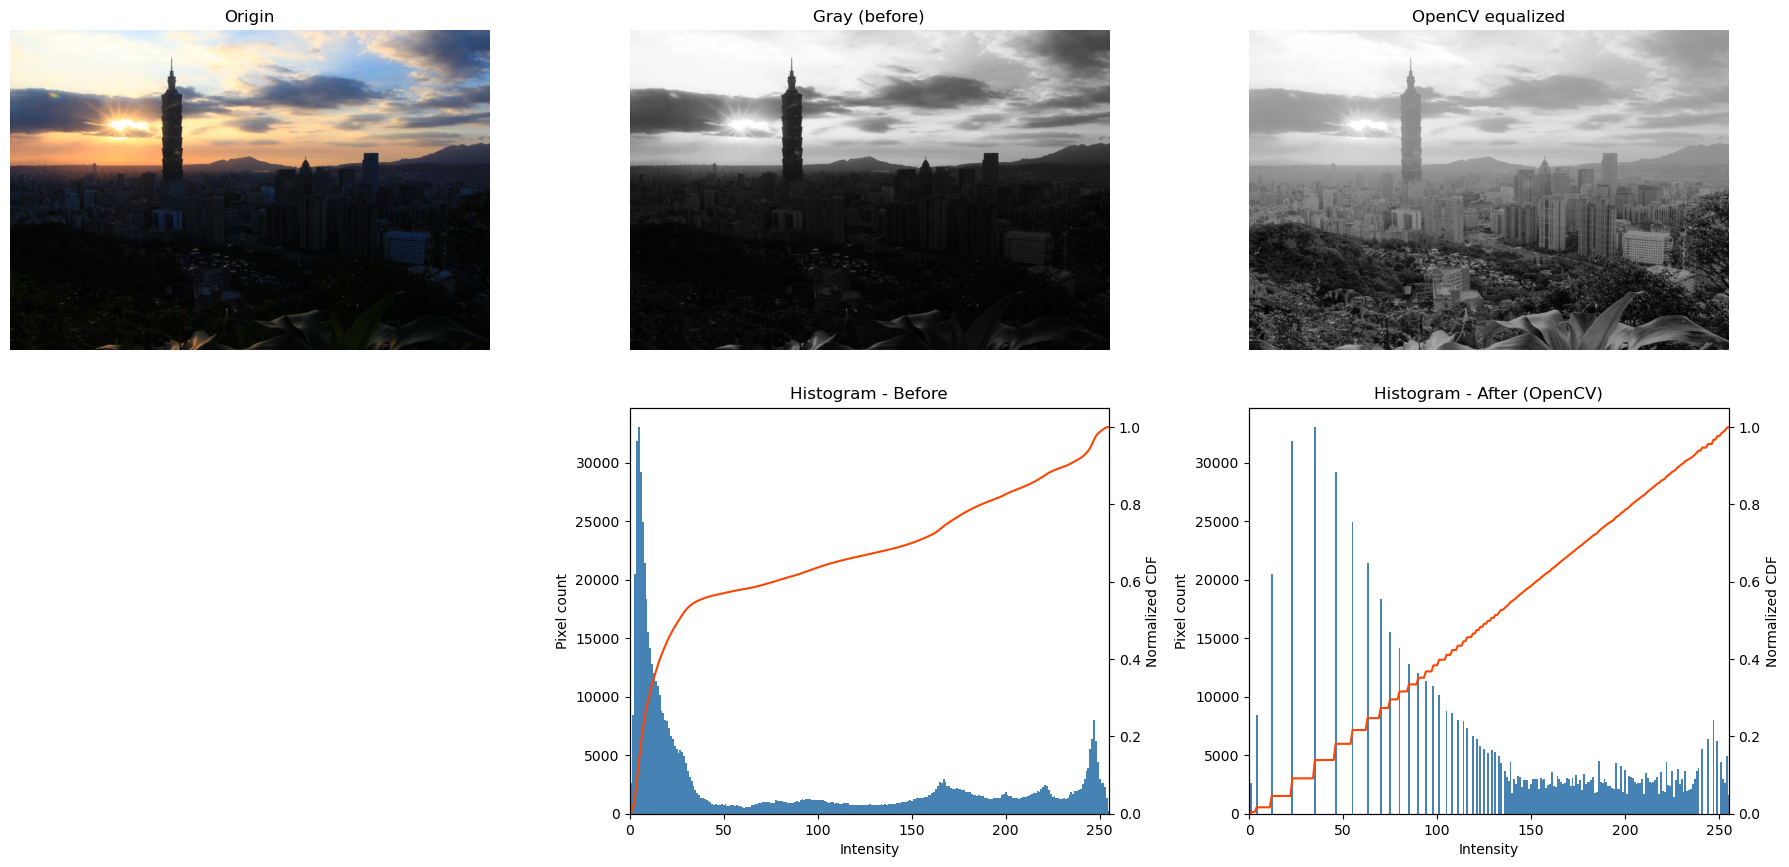

In [128]:
img_rgb_cv2, gray_cv2, eq_cv = q2.OpenCV_Histogram(IMAGE_PATH2, records2)


## 比較執行速度與轉換結果

左下到右下依序是等化前、NumPy 等化後、OpenCV 等化後的直方圖（藍色長條）與正規化 CDF（橘線）。
等化後的 CDF 應接近一條斜直線，代表灰階分布已被拉平。


=== 執行紀錄 ===
 1. NumPy     4.246 ms | 平均灰階: 129.32
 2. OpenCV    3.228 ms | 平均灰階: 129.32
 3. NumPy     6.886 ms | 平均灰階: 129.32
 4. NumPy     4.355 ms | 平均灰階: 129.32
 5. NumPy     8.328 ms | 平均灰階: 129.32
 6. NumPy     9.878 ms | 平均灰階: 129.32
 7. NumPy     4.955 ms | 平均灰階: 129.32
 8. NumPy     4.764 ms | 平均灰階: 129.32
 9. NumPy     4.089 ms | 平均灰階: 129.32
10. NumPy     3.984 ms | 平均灰階: 129.32
11. NumPy     3.873 ms | 平均灰階: 129.32
12. NumPy     3.639 ms | 平均灰階: 129.32
13. NumPy     4.274 ms | 平均灰階: 129.32
14. NumPy     3.837 ms | 平均灰階: 129.32
15. NumPy     3.857 ms | 平均灰階: 129.32
16. NumPy     4.069 ms | 平均灰階: 129.32
17. NumPy     4.091 ms | 平均灰階: 129.32
18. NumPy     4.030 ms | 平均灰階: 129.32
19. NumPy     4.002 ms | 平均灰階: 129.32
20. NumPy     5.035 ms | 平均灰階: 129.32
21. NumPy     4.818 ms | 平均灰階: 129.32
22. NumPy     5.191 ms | 平均灰階: 129.32
23. NumPy     4.205 ms | 平均灰階: 129.32
24. NumPy     3.427 ms | 平均灰階: 129.32
25. NumPy     4.131 ms | 平均灰階: 129.32
26. NumPy     4.688 ms | 平均灰階: 129.32

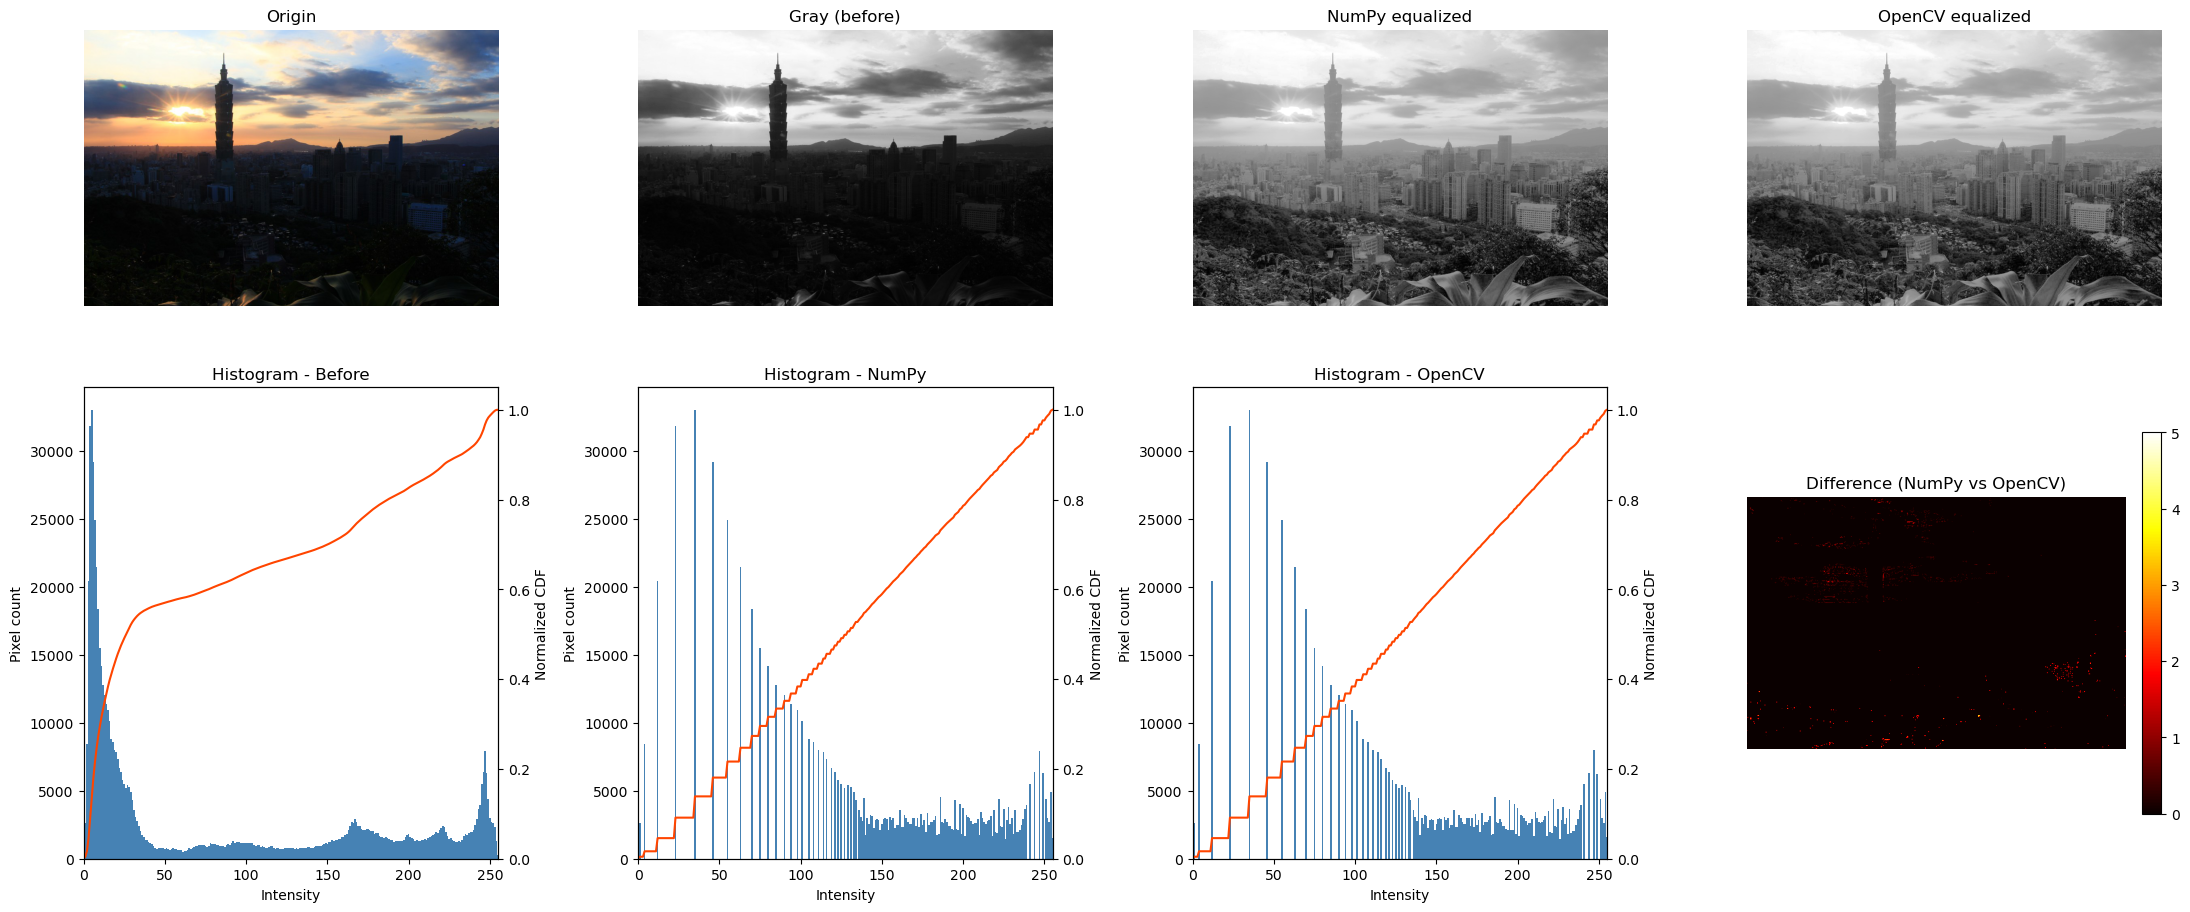

In [131]:
q2.analyze_records(records2, eq_numpy, eq_cv, img_rgb2)
